In [1]:
# # For CUDA 11.8 (as indicated by +cu118 in your version)
# !pip install --upgrade torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

# If the above doesn't get you a PyTorch version >= 2.3.0, you might need to add --pre
# but try the first command first.
# !pip install --upgrade --pre torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

In [2]:
# pip install pandas numpy matplotlib seaborn scikit-learn torch torchvision pillow opencv-python jupyterlab

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from torchvision import transforms
from PIL import Image
import cv2

In [4]:

# import scipy.io
# import numpy as np
# import pandas as pd
# from datetime import datetime
# import os

# # 1. .mat 파일 로드
# mat = scipy.io.loadmat('/kaggle/input/imdb-wiki-faces-dataset/imdb_crop/imdb.mat') 

# # 2. 메타데이터 추출
# data = mat['imdb'][0][0]
# photo_taken = data['photo_taken'][0]
# dob = data['dob'][0]
# full_path = [str(x[0]) for x in data['full_path'][0]]
# # 3. 생년 → 연도로 변환
# def matlab_datenum_to_year(matlab_datenum):
#     if matlab_datenum > 0:
#         try:
#             return datetime.fromordinal(int(matlab_datenum)).year
#         except:
#             return None
#     return None

# # 4. 나이 계산
# ages = []
# for d, taken in zip(dob, photo_taken):
#     birth_year = matlab_datenum_to_year(d)
#     if birth_year is not None:
#         ages.append(taken - birth_year)
#     else:
#         ages.append(None)

# # 5. DataFrame 생성 및 정제
# df3 = pd.DataFrame({'ID': full_path, 'age': ages})
# df3 = df3[df3['age'].between(0, 100)].dropna()

# bins_exact = [0, 11, 21, 31, 41, 51, float('inf')]
# age_labels_exact = ['0~10', '11~20', '21~30', '31~40', '41~50', 'over50'] # Corrected label for 41-50
# df3['label'] = pd.cut(df3['age'],
#                          bins=bins_exact,
#                          labels=age_labels_exact,
#                          right=False) # 왼쪽 경계 포함, 오른쪽 경계 미포함 (예: [0, 11)은 0부터 10까지)
# df3 =df3.drop('age',axis=1)

# age_map = {
#     '0~10':0,
#     '11~20':1,
#     '21~30':2,
#     '31~40':3,
#     '41~50':4,
#     'over50': 5
# }

# df3['class'] = df3['label'].map(age_map)

# df3['full_path'] = df3['ID'].apply(lambda x: os.path.join("/kaggle/input/imdb-wiki-faces-dataset/imdb_crop", x))
# print("--- pd.cut()을 사용하여 나이대 매핑된 DataFrame (권장) ---")
# df3.head()
# df3['label'].value_counts() # 요거는 따로 코드 셀에서 실행!!


In [5]:
# print("--- pd.cut()을 사용하여 나이대 매핑된 DataFrame (권장) ---")
# df3.head()

In [6]:
# df3['label'].value_counts()

In [7]:
# 전처리 단계

In [8]:
df = pd.read_csv("/kaggle/input/datasetaing1/train_dataset/train_dataset/train.csv")

In [9]:
df.head()

,ID,label
0,45666944@N00/landmark_aligned_face.408.1184301...,31~40
1,45666944@N00/landmark_aligned_face.407.1184317...,0~10
2,45666944@N00/landmark_aligned_face.406.1184271...,31~40
3,45666944@N00/landmark_aligned_face.411.1184215...,41~50
4,45666944@N00/landmark_aligned_face.410.1184317...,0~10


In [10]:
age_map = {
    '0~10':0,
    '11~20':1,
    '21~30':2,
    '31~40':3,
    '41~50':4,
    'over50': 5
}

df['class'] = df['label'].map(age_map)

print(df.head())


                                                  ID  label  class
0  45666944@N00/landmark_aligned_face.408.1184301...  31~40      3
1  45666944@N00/landmark_aligned_face.407.1184317...   0~10      0
2  45666944@N00/landmark_aligned_face.406.1184271...  31~40      3
3  45666944@N00/landmark_aligned_face.411.1184215...  41~50      4
4  45666944@N00/landmark_aligned_face.410.1184317...   0~10      0


In [11]:
base_path ='/kaggle/input/datasetaing1/train_dataset/train_dataset/train'
df['full_path'] = df['ID'].apply(lambda x: os.path.join(base_path, x))
print(df['label'].value_counts())


label
0~10      5239
21~30     3570
31~40     1842
11~20     1505
over50     743
41~50      624
Name: count, dtype: int64


In [ ]:
df2 = df[df['label']='over50' & df['label']= '41~50' ]

In [12]:
# df2 = pd.read_csv("/kaggle/input/aingtrain/train_2.csv")
# base_path = '/kaggle/input/utkface-new/UTKFace'
# df2['full_path'] = df2['ID'].apply(lambda x: os.path.join(base_path, x))
# df2.head()

,ID,label,class,full_path
0,26_0_2_20170104023102422.jpg.chip.jpg,21~30,2,/kaggle/input/utkface-new/UTKFace/26_0_2_20170...
1,22_1_1_20170112233644761.jpg.chip.jpg,21~30,2,/kaggle/input/utkface-new/UTKFace/22_1_1_20170...
2,21_1_3_20170105003215901.jpg.chip.jpg,21~30,2,/kaggle/input/utkface-new/UTKFace/21_1_3_20170...
3,28_0_0_20170117180555824.jpg.chip.jpg,21~30,2,/kaggle/input/utkface-new/UTKFace/28_0_0_20170...
4,17_1_4_20170103222931966.jpg.chip.jpg,11~20,1,/kaggle/input/utkface-new/UTKFace/17_1_4_20170...


In [13]:
# df2['label'].value_counts()

label
21~30     7784
over50    4608
31~40     4339
0~10      3218
41~50     2100
11~20     1659
Name: count, dtype: int64

In [14]:
df_comb= df

df_comb['label'].value_counts()

label
21~30     11354
0~10       8457
31~40      6181
over50     5351
11~20      3164
41~50      2724
Name: count, dtype: int64

[ WARN:0@0.782] global loadsave.cpp:268 findDecoder imread_('/kaggle/input/utkface-new/UTKFace/114841417@N06/landmark_aligned_face.493.12101541316_35e1f0b9a1_o.jpg'): can't open/read file: check file path/integrity


error: OpenCV(4.11.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'


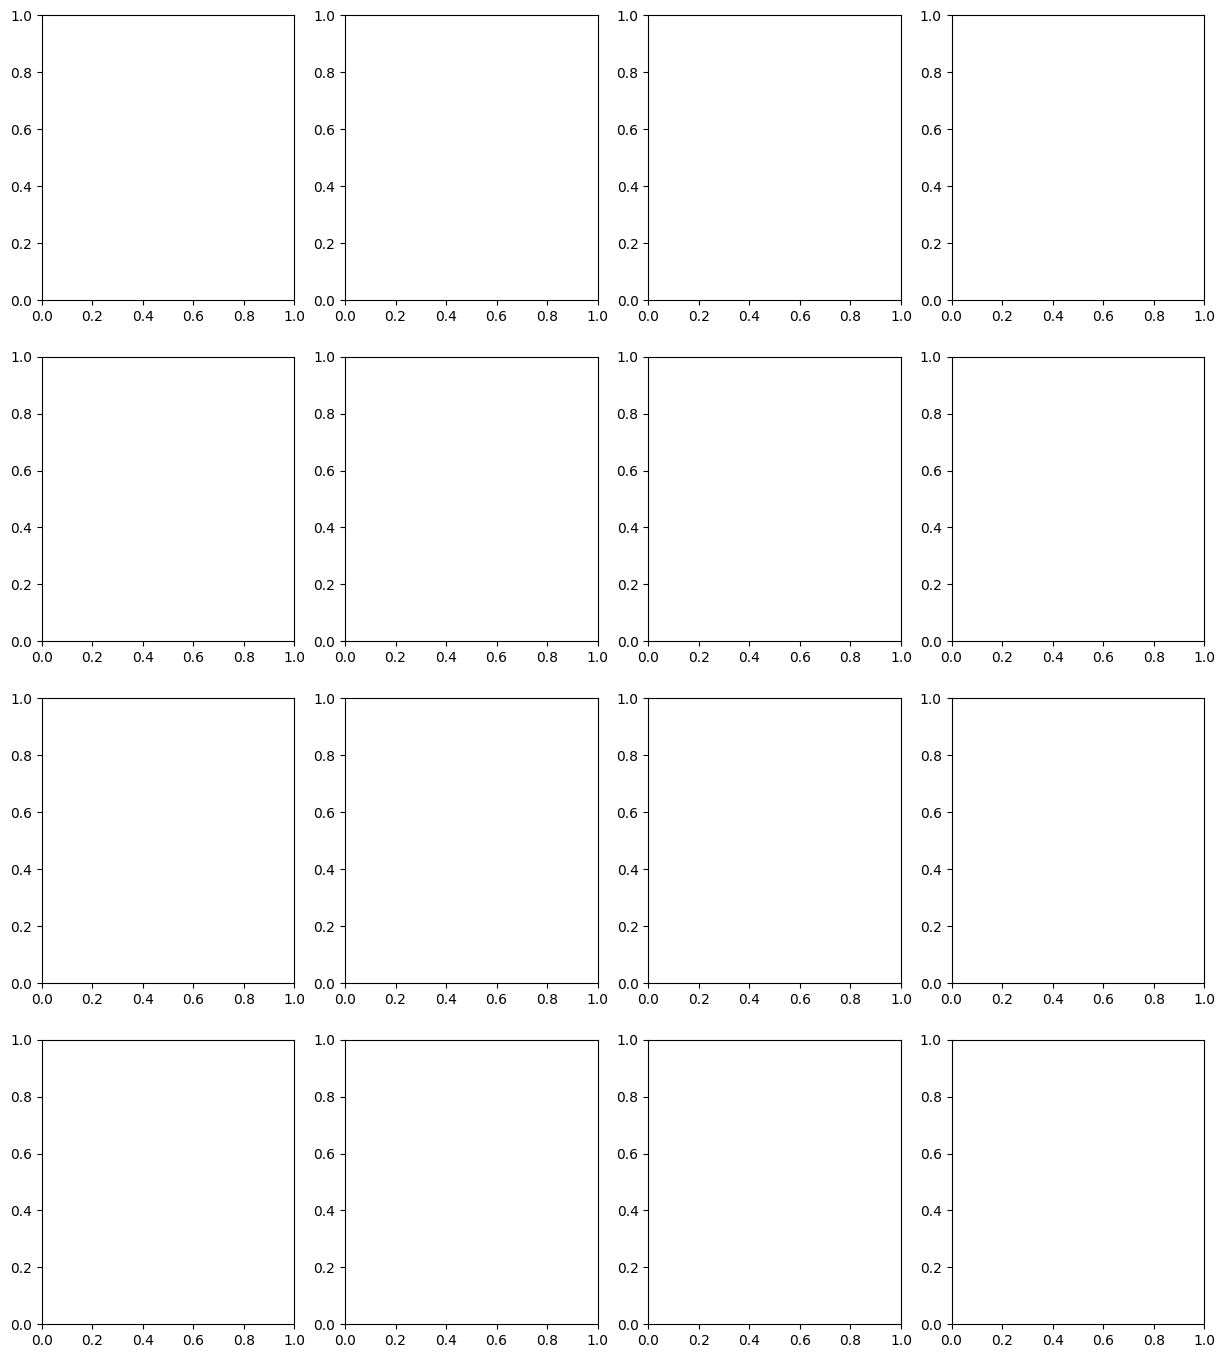

In [15]:
import math
import numpy as np
import cv2
import matplotlib.pyplot as plt

n = 16
random_indices = np.random.choice(df.index.tolist(), size=n, replace=False)

n_cols = 4
n_rows = math.ceil(n / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 17))
axes = axes.flatten()

for i, x in enumerate(random_indices):
    ax = axes[i]
    imgpath = '/kaggle/input/utkface-new/UTKFace/' + df.loc[x, 'ID']
    img = cv2.imread(imgpath)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    age_label = df.loc[x, 'label']
    ax.set_title(f"age: {age_label}", fontsize=12)
    ax.axis('off')  # Optional: remove axis ticks

# Hide unused axes
for j in range(n, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import math

n=16
random_indices = np.random.choice(df.index.tolist(), size=n) #
n_cols = 4
n_rows = math.ceil(n / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 17))
axes = axes.flatten() 
for i, x in enumerate(random_indices):
   ax = axes[i]
   imgpath ='/kaggle/input/utkface-new/UTKFace/' + df['ID'][x]
   img = cv2.imread(imgpath) # df['ID'] = img_path
   img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
   ax.imshow(img)
   age_label = df['label'][x]
   ax.set_title(f"age: {age_label}",fontsize=12)

In [ ]:
from torchvision import transforms
from torch.utils.data import Dataset
from PIL import Image

class AgeDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)


    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        # CSV에서 파일명과 라벨 읽기
        row = self.df.iloc[idx]
        class_label = row['class']
        image_path = row['full_path']
        
        # PIL로 이미지 로드
        image = Image.open(image_path).convert('RGB')
        
        # __init__에서 설정된 전처리 적용
        # 여기서는 if문이 필요 없습니다. self.transform에 이미 적절한 전처리 파이프라인이 할당되어 있습니다
            
        return image, class_label

In [ ]:
# DatasetWrapper (random_split된 Subset에 transform 적용)
class DatasetWrapper(Dataset):
    def __init__(self, dataset, transform=None):
        self.dataset = dataset
        self.transform = transform

    def __getitem__(self, idx):
        img, label = self.dataset[idx] 
        # 원본 Dataset의 __getitem__이 PIL Image를 반환한다고 가정
        if self.transform:
            img = self.transform(img)
        return img, label

    def __len__(self):
        return len(self.dataset)



# --- 2. 통합된 전처리 정의 ---
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224,scale=(0.8,1.2)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.3,hue=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.RandomPerspective(distortion_scale=0.2,p=0.3),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x + 0.01 * torch.randn_like(x)),
    transforms.RandomErasing(p=0.5,scale=(0.02,0.2),ratio=(0.3,3.3),value=0),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
])

val_test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
# import pandas as pd
# from PIL import Image
# import os
# import numpy as np

# def add_grayscale_status_to_df_optimized(
#     df: pd.DataFrame,
#     image_path_col: str = 'full_path',
#     threshold: int = 5,
#     sample_size: tuple = (100, 100) # Size for downsampling for pixel check
# ) -> pd.DataFrame:
#     """
#     Adds an 'is_grayscale' column to a DataFrame, indicating if the image
#     at the specified path is grayscale. Optimized for memory efficiency.

#     Args:
#         df (pd.DataFrame): The input DataFrame.
#         image_path_col (str): The name of the column containing image full paths.
#         threshold (int): The maximum allowed difference between R, G, B channels
#                          for an image to be considered grayscale.
#         sample_size (tuple): The size to which an RGB image is downsampled
#                              before checking pixel by pixel for grayscale.
#                              Set to None to disable downsampling.

#     Returns:
#         pd.DataFrame: A new DataFrame with the 'is_grayscale' column added.
#     """
#     df_copy = df.copy()
#     grayscale_status = []

#     for index, row in df_copy.iterrows():
#         image_path = row[image_path_col]
#         is_grayscale = False

#         try:
#             img = Image.open(image_path)

#             # --- Optimization 1: Check image bands directly ---
#             if img.getbands() == ('L',): # 'L' band means it's already grayscale
#                 is_grayscale = True
#             else:
#                 # Convert to RGB if not already (handles 'RGBA', 'P' etc.)
#                 # This ensures we have R, G, B channels to compare
#                 img = img.convert('RGB')

#                 # --- Optimization 2: Downsample for pixel check ---
#                 if sample_size and img.size[0] > sample_size[0] and img.size[1] > sample_size[1]:
#                     img_for_check = img.resize(sample_size, Image.LANCZOS) # Use a high-quality filter
#                 else:
#                     img_for_check = img

#                 # --- Optimization 3 (Alternative): Using NumPy for pixel check ---
#                 # This can be faster for larger images (even after downsampling)
#                 # compared to iterating through img.getdata() in pure Python.
#                 pixels = np.array(img_for_check)
#                 # Reshape to (num_pixels, 3) if not already
#                 if pixels.ndim == 3: # (height, width, channels)
#                     pixels = pixels.reshape(-1, 3)

#                 # Check if all channels are similar within the threshold
#                 all_channels_similar = True
#                 for r, g, b in pixels:
#                     if abs(r - g) > threshold or \
#                        abs(g - b) > threshold or \
#                        abs(b - r) > threshold:
#                         all_channels_similar = False
#                         break # Found a significant color difference, it's a color image

#                 if all_channels_similar:
#                     is_grayscale = True

#         except FileNotFoundError:
#             print(f"오류: 파일 '{image_path}'을(를) 찾을 수 없습니다.")
#             is_grayscale = False # Cannot determine, treat as not grayscale
#         except Exception as e:
#             print(f"오류: '{image_path}' 처리 중 오류 발생 - {e}")
#             is_grayscale = False # Error occurred, treat as not grayscale

#         grayscale_status.append(is_grayscale)

#     df_copy['is_grayscale'] = grayscale_status
#     print("그레이스케일 여부 확인 완료.")
#     return df_copy

In [ ]:
# import pandas as pd
# from PIL import Image
# import os

# def add_grayscale_status_to_df(df: pd.DataFrame, image_path_col: str = 'full_path', new_df_name: str = 'dfg', threshold: int = 5) -> pd.DataFrame:
#     dfg = df.copy()

#     grayscale_status=[]
#     for index, row in df.iterrows():
#         image_path = row[image_path_col]
#         is_grayscale = False
#         try:
#             img = Image.open(image_path).convert('RGB')
#             pixels = img.getdata()
#             all_channels_similar= True
#             for r, g, b in pixels:
#                     if abs(r - g) > threshold or \
#                        abs(g - b) > threshold or \
#                        abs(b - r) > threshold:
#                         all_channels_similar = False
#                         break # 하나라도 조건을 벗어나면 컬러 이미지로 판단하고 루프 종료
                
#             if all_channels_similar:
#                     is_grayscale = True
    
#         except Exception as e:
#                 print(f"오류: '{image_path}' 처리 중 오류 발생 - {e}")
#                 # 오류 발생 시 그레이스케일 여부를 알 수 없으므로 False로 처리
#                 is_grayscale = False

#         grayscale_status.append(is_grayscale)
#     # 새로운 'is_grayscale' 열 추가
#     dfg['is_grayscale'] = grayscale_status

#     print("그레이스케일 여부 확인 완료.")
#     return dfg

In [ ]:
# df_result = add_grayscale_status_to_df(df3, image_path_col='full_path')
# print(df_result.head())

In [ ]:
# print("\n--- 새로운 df (그레이스케일 여부 추가됨)의 클래스별 스케일여부 ---")
# print(df_result[df_result['is_grayscale']== True]['class'].value_counts())

In [ ]:
# 훈련 단계 12000 23700개
# 13500 + 23700 = 37200
# 33480 3720
# 33480 훈련에 사용
# 3720 은 13500에서 가져옴. # 0.276 0.724
# 

In [ ]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # cpu가 아니면 더하고.

In [ ]:
df_sp1,df_sp2 = train_test_split(
    df,test_size = 0.3,
    random_state=42,
    stratify=df['class'] if 'class' in df.columns else None
)
train_df = df_sp1

In [ ]:
val_df = df_sp2
print(f"\n데이터 분할:")
print(f"  훈련: {len(train_df)}개")
print(f"  검증: {len(val_df)}개")

In [ ]:
train_dataset = AgeDataset(train_df)
val_dataset = AgeDataset(val_df)

In [ ]:
train_dataset_final = DatasetWrapper(train_dataset, transform=train_transform)
val_dataset_final = DatasetWrapper(val_dataset, transform=val_test_transform)

In [ ]:

# 데이터 배치 생성
train_loader = DataLoader(train_dataset_final, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset_final, batch_size=64, shuffle=False, num_workers=2)

print(f"\n데이터로더 생성 완료:")
print(f"  훈련 배치: {len(train_loader)}")
print(f"  검증 배치: {len(val_loader)}")

In [ ]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # cpu가 아니면 더하고.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
# class AgeClassifier(nn.Module):
#     def __init__(self, num_classes=6):
#         super(AgeClassifier, self).__init__()

#         # ResNet18 백본 모델 로딩 및 FC 레이어 제거
#         self.backbone = models.resnet18(weights=None)
#         self.backbone.fc = nn.Identity()  # FC 레이어 제거
#         self.mlp_head = nn.Sequential(
#             nn.Linear(512, 64),
#             nn.ReLU(inplace=True),
#             nn.Dropout(0.3),
#             nn.Linear(64, num_classes)
#         )

#         self._initialize_weights()

#     def _initialize_weights(self):
#         for m in self.mlp_head:
#             if isinstance(m, nn.Linear):
#                 nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
#                 if m.bias is not None:
#                     nn.init.constant_(m.bias, 0)

#     def forward(self, x):
#         x = self.backbone(x)            
#         return self.mlp_head(x)           # (B, num_classes)

In [ ]:
import torch.nn as nn
import torchvision.models as models

class AgeClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = models.resnet18(weights=None)
        self.backbone.fc = nn.Identity()  # fc는 사용하지 않음
        self.avgpool = nn.AdaptiveAvgPool2d((1,1))
        self.spatialdropout = nn.Dropout2d(p=0.2)
        self.classifier = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, padding=1, groups=512, bias=False),  # Depthwise
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=0.2),
            
            nn.Conv2d(512,64, kernel_size=1, bias=False),  # Pointwise
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        
            nn.Dropout2d(p=0.3),
            nn.Conv2d(64, num_classes, kernel_size=1))
            
    def forward(self, x):
        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = self.backbone.relu(x)
        x = self.backbone.maxpool(x)
    
        x = self.backbone.layer1(x)
        x = self.backbone.layer2(x)
        x = self.backbone.layer3(x)
        x = self.backbone.layer4(x)

        x = self.spatialdropout(x)
        x = self.classifier(x)         # classifier에서 이미 Conv2d 사용
        x = self.avgpool(x)            # → (B, num_classes, 1, 1)
        x = x.squeeze(-1).squeeze(-1)  # → (B, num_classes)
        return x

In [ ]:
# import torch.nn as nn
# import torchvision.models as models

# class AgeClassifier(nn.Module):
#     def __init__(self, num_classes):
#         super().__init__()
#         self.backbone = models.resnet18(weights=None)
#         self.backbone.fc = nn.Identity()  # fc는 사용하지 않음


#         # 1×1 Conv로 채널 축소 → ReLU → Dropout → 최종 분류
#         self.classifier = nn.Sequential(
#             nn.Conv2d(512, 128, kernel_size=1, bias=False),
#             nn.BatchNorm2d(128),
#             nn.ReLU(inplace=True),
#             nn.Dropout(p=0.4),
#             nn.Conv2d(128, num_classes, kernel_size=1)  # age 클래스 수
#         )
#         self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

#     def forward(self, x):
#         x = self.backbone.conv1(x)
#         x = self.backbone.bn1(x)
#         x = self.backbone.relu(x)
#         x = self.backbone.maxpool(x)

#         x = self.backbone.layer1(x)
#         x = self.backbone.layer2(x)
#         x = self.backbone.layer3(x)
#         x = self.backbone.layer4(x)

#         x = self.classifier(x)
#         x = self.avgpool(x)            # (B, num_classes, 1, 1)
#         return x.view(x.size(0), -1)   # (B, num_classes)

In [ ]:
from torch.utils.data import DataLoader

class EarlyStopping:
    def __init__(self, patience=5, delta=0.01, mode='min'):
        """
        30 에폭에 최적화된 Early Stopping
        
        Args:
            patience: 짧게 설정 (5-7)
            delta: 민감하게 설정 (0.001)
            mode: 'min' for loss, 'max' for accuracy
        """
        self.patience = patience
        self.delta = delta
        self.mode = mode
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_model_state = None
        
    def __call__(self, val_metric, model):
        score = -val_metric if self.mode == 'min' else val_metric
        
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(model)
            self.counter = 0
            
        return self.early_stop
    
    def save_checkpoint(self, model):
        """모델 상태 저장"""
        self.best_model_state = model.state_dict().copy()

In [ ]:
early_stopping = EarlyStopping(patience=5,delta = 0.01)

In [ ]:
def train_model(model, train_loader, val_loader, num_epochs=20):
    print(f"사용 디바이스: {DEVICE}")
    model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    best_wd = None
    wd_list =[1e-3]
    for wd in wd_list:
        print(f"Trying weight_decay = {wd}")
        optimizer = torch.optim.AdamW(model.parameters(), lr=0.0015,weight_decay=wd)
        
        # scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode='min',factor=0.3,patience=3, threshold=4e-2,threshold_mode='rel',verbose=True)
        # scheduler = torch.optim.lr_scheduler.CyclicLR(optimizer, base_lr=0.00001, max_lr=0.001, step_size_up=2, step_size_down= 4, mode='triangular2')
        # #scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        # optimizer,
        # mode='max',        # 검증 정확도(Val Acc)를 모니터링할 것이므로 'max'
        # factor=0.5,        # LR을 10배 감소
        # patience=3,        # 5 에포크 동안 '의미 있는' 개선이 없으면 LR 감소
        # threshold=0.02,   # 정확도가 베스트 최고치 대비 0.02 (2%p) 이상 개선되어야 '개선'으로 간주
        # threshold_mode='abs', # 상대적 변화 (e.g., (new_val_acc - best_val_acc) / best_val_acc > threshold)     # LR 감소 시 출력
        # min_lr=1e-7        # 최소 학습률)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer,T_0=5,T_mult=1,eta_min=5e-5,last_epoch=-1)
    
        # 훈련 과정 기록
        train_losses, val_losses = [], []
        train_accs, val_accs = [], []
        
        best_val_acc = 0.0 # 최고 성능인 검증 데이터 기록전 초기화
        
        for epoch in range(num_epochs):
            # 훈련 단계
            model.train() # 모델 훈련
            running_loss = 0.0
            correct_train = 0
            total_train = 0
            
            for batch_idx, (images, labels) in enumerate(train_loader): # 훈련 로더에서 배치를 가져온다.
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                
                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                running_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total_train += labels.size(0)
                correct_train += (predicted == labels).sum().item()
    
                # 진행상황 출력
                if batch_idx % 100 == 0:
                    print(f'Epoch {epoch+1}/{num_epochs},Learning Rate: {scheduler.get_last_lr()[0]:.8f}, Batch {batch_idx}/{len(train_loader)}, Loss: {loss.item():.4f}')
            
            # 검증 단계
            model.eval()
            val_loss = 0.0
            correct_val = 0
            total_val = 0
            
            with torch.no_grad():
                for images, labels in val_loader:
                    images, labels = images.to(DEVICE), labels.to(DEVICE)
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                    
                    val_loss += loss.item()
                    _, predicted = torch.max(outputs.data, 1)
                    total_val += labels.size(0)
                    correct_val += (predicted == labels).sum().item()
            
            # 에포크 결과 계산
            epoch_train_loss = running_loss / len(train_loader)
            epoch_train_acc = 100 * correct_train / total_train
            epoch_val_loss = val_loss / len(val_loader)
            epoch_val_acc = 100 * correct_val / total_val
            
            train_losses.append(epoch_train_loss)
            train_accs.append(epoch_train_acc)
            val_losses.append(epoch_val_loss)
            val_accs.append(epoch_val_acc)
            
            print(f'Epoch {epoch+1}/{num_epochs}:')
            print(f'  Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}%')
            print(f'  Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%')
            print('-' * 60)
            
            # 최고 모델 저장
            if epoch_val_acc > best_val_acc:
                best_val_acc = epoch_val_acc
                torch.save(model1.state_dict(), '/kaggle/working/best_model.pth')
                best_wd = wd
            scheduler.step()
            if early_stopping(val_loss, model):
                print(f'Early stopping triggered at epoch {epoch+1}')
            # 최고 성능 모델로 복원
                model.load_state_dict(early_stopping.best_model_state)
                break
    print(f"Best weight_decay: {best_wd} with accuracy {best_val_acc:.4f}")
        
    return train_losses, train_accs, val_losses, val_accs


In [ ]:
def train_model2(model, train_loader, val_loader, num_epochs=20):
    print(f"사용 디바이스: {DEVICE}")
    model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    best_wd = None
    wd_list =[1e-3]
    for wd in wd_list:
        print(f"Trying weight_decay = {wd}")
        optimizer = torch.optim.AdamW(model.parameters(), lr=0.0015,weight_decay=wd)
        
        # scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode='min',factor=0.3,patience=3, threshold=4e-2,threshold_mode='rel',verbose=True)
        # scheduler = torch.optim.lr_scheduler.CyclicLR(optimizer, base_lr=0.00001, max_lr=0.001, step_size_up=2, step_size_down= 4, mode='triangular2')
        # #scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        # optimizer,
        # mode='max',        # 검증 정확도(Val Acc)를 모니터링할 것이므로 'max'
        # factor=0.5,        # LR을 10배 감소
        # patience=3,        # 5 에포크 동안 '의미 있는' 개선이 없으면 LR 감소
        # threshold=0.02,   # 정확도가 베스트 최고치 대비 0.02 (2%p) 이상 개선되어야 '개선'으로 간주
        # threshold_mode='abs', # 상대적 변화 (e.g., (new_val_acc - best_val_acc) / best_val_acc > threshold)     # LR 감소 시 출력
        # min_lr=1e-7        # 최소 학습률)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer,T_0=5,T_mult=1,eta_min=5e-5,last_epoch=-1)
    
        # 훈련 과정 기록
        train_losses, val_losses = [], []
        train_accs, val_accs = [], []
        
        best_val_acc = 0.0 # 최고 성능인 검증 데이터 기록전 초기화
        
        for epoch in range(num_epochs):
            # 훈련 단계
            model.train() # 모델 훈련
            running_loss = 0.0
            correct_train = 0
            total_train = 0
            
            for batch_idx, (images, labels) in enumerate(train_loader): # 훈련 로더에서 배치를 가져온다.
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                
                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                running_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total_train += labels.size(0)
                correct_train += (predicted == labels).sum().item()
    
                # 진행상황 출력
                if batch_idx % 100 == 0:
                    print(f'Epoch {epoch+1}/{num_epochs},Learning Rate: {scheduler.get_last_lr()[0]:.8f}, Batch {batch_idx}/{len(train_loader)}, Loss: {loss.item():.4f}')
            
            # 검증 단계
            model.eval()
            val_loss = 0.0
            correct_val = 0
            total_val = 0
            
            with torch.no_grad():
                for images, labels in val_loader:
                    images, labels = images.to(DEVICE), labels.to(DEVICE)
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                    
                    val_loss += loss.item()
                    _, predicted = torch.max(outputs.data, 1)
                    total_val += labels.size(0)
                    correct_val += (predicted == labels).sum().item()
            
            # 에포크 결과 계산
            epoch_train_loss = running_loss / len(train_loader)
            epoch_train_acc = 100 * correct_train / total_train
            epoch_val_loss = val_loss / len(val_loader)
            epoch_val_acc = 100 * correct_val / total_val
            
            train_losses.append(epoch_train_loss)
            train_accs.append(epoch_train_acc)
            val_losses.append(epoch_val_loss)
            val_accs.append(epoch_val_acc)
            
            print(f'Epoch {epoch+1}/{num_epochs}:')
            print(f'  Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}%')
            print(f'  Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%')
            print('-' * 60)
            
            # 최고 모델 저장
            if epoch_val_acc > best_val_acc:
                best_val_acc = epoch_val_acc
                torch.save(model2.state_dict(), '/kaggle/working/best_model2.pth')
                best_wd = wd
            scheduler.step()
            if early_stopping(val_loss, model):
                print(f'Early stopping triggered at epoch {epoch+1}')
            # 최고 성능 모델로 복원
                model.load_state_dict(early_stopping.best_model_state)
                break
    print(f"Best weight_decay: {best_wd} with accuracy {best_val_acc:.4f}")
        
    return train_losses, train_accs, val_losses, val_accs


In [ ]:
# 모델 생성
model1 = AgeClassifier(num_classes=6)
print(f"모델 파라미터 수: {sum(p.numel() for p in model.parameters()):,}")

# 훈련 시작
print(f"\n모델 훈련 시작...")
train_losses, train_accs, val_losses, val_accs = train_model(
    model1, train_loader, val_loader, num_epochs=40
)

print(f"\n훈련 완료!")
print(f"최고 검증 정확도: {max(val_accs):.2f}%")

In [ ]:
# 모델 생성
model2 = AgeClassifier(num_classes=6)
print(f"모델 파라미터 수: {sum(p.numel() for p in model.parameters()):,}")

# 훈련 시작
print(f"\n모델 훈련 시작...")
train_losses2, train_accs2, val_losses2, val_accs2 = train_model2(
    model2, train_loader, val_loader, num_epochs=40
)

print(f"\n훈련 완료!")
print(f" 두번째 최고 검증 정확도: {max(val_accs2):.2f}%")

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
from scipy.optimize import minimize
from sklearn.metrics import log_loss, accuracy_score, classification_report, confusion_matrix

# ================================
# 1. 모델 저장 (훈련 후)
# ================================

# ================================
# 2. 저장된 모델들 불러오기
# ================================
def load_trained_models(model_paths, device='cuda'):
    """
    저장된 .pth 파일들을 불러와서 모델 리스트 반환
    """
    models = []
    
    for i, model_path in enumerate(model_paths):
        print(f"모델 {i+1} 로딩중: {model_path}")
        
        # 모델 구조 생성
        model = AgeClassifier(num_classes=6)
        
        # 저장된 가중치 로드
        model.load_state_dict(torch.load(model_path, map_location=device))
        
        # 평가 모드로 설정
        model.eval()
        model.to(device)
        
        models.append(model)
        print(f"모델 {i+1} 로딩 완료!")
    
    return models

# ================================
# 3. 각 모델의 예측 확률 추출
# ================================
def get_model_predictions(models, data_loader, device='cuda'):
    """
    각 모델에서 예측 확률들을 추출
    """
    all_predictions = []  # 각 모델의 예측을 저장할 리스트
    all_labels = []
    
    # 각 모델별로 예측 수행
    for i, model in enumerate(models):
        print(f"\n모델 {i+1} 예측 수행 중...")
        
        model_preds = []
        labels = []
        
        with torch.no_grad():
            for batch_idx, (data, target) in enumerate(data_loader):
                data, target = data.to(device), target.to(device)
                
                # 모델 예측 (logits)
                outputs = model(data)
                
                # Softmax로 확률 변환
                probabilities = F.softmax(outputs, dim=1)
                
                # CPU로 이동 후 numpy 변환
                model_preds.append(probabilities.cpu().numpy())
                
                # 첫 번째 모델에서만 라벨 저장 (모든 모델이 같은 라벨 사용)
                if i == 0:
                    labels.append(target.cpu().numpy())
        
        # 배치들을 하나로 합치기
        model_predictions = np.vstack(model_preds)
        all_predictions.append(model_predictions)
        
        if i == 0:
            all_labels = np.hstack(labels)
        
        print(f"모델 {i+1} 예측 완료: {model_predictions.shape}")
    
    return all_predictions, all_labels

# ================================
# 4. 앙상블 최적화 (위에서 만든 함수들 사용)
# ================================
def weighted_predictions(weights, predictions_list):
    """
    가중치를 적용한 앙상블 예측
    """
    weighted_preds = np.zeros_like(predictions_list[0])
    for i, pred in enumerate(predictions_list):
        weighted_preds += weights[i] * pred
    return weighted_preds

def objective_function(weights, predictions_list, y_true):
    """
    최소화할 목적 함수 (log loss)
    """
    weighted_preds = weighted_predictions(weights, predictions_list)
    # 확률 정규화
    weighted_preds = weighted_preds / weighted_preds.sum(axis=1, keepdims=True)
    return log_loss(y_true, weighted_preds)

def optimize_ensemble_weights(predictions_list, y_true):
    """
    최적의 앙상블 가중치 찾기
    """
    n_models = len(predictions_list)
    
    # 초기 가중치 (동일하게)
    initial_weights = np.ones(n_models) / n_models
    
    # 제약조건
    bounds = [(0, 1)] * n_models
    constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
    
    print(f"\n{n_models}개 모델의 최적 가중치 찾는 중...")
    
    # 최적화 실행
    result = minimize(
        objective_function,
        initial_weights,
        args=(predictions_list, y_true),
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'disp': True}
    )
    
    return result.x, result

# ================================
# 5. 전체 앙상블 파이프라인
# ================================
def ensemble_age_models(model_paths, test_loader, age_classes, device='cuda'):
    """
    전체 앙상블 과정을 실행하는 메인 함수
    """
    print("="*60)
    print("나이 분류 모델 앙상블 시작")
    print("="*60)
    
    # 1. 모델들 로드
    models = load_trained_models(model_paths, device)
    
    # 2. 각 모델의 예측 확률 추출
    predictions_list, y_true = get_model_predictions(models, test_loader, device)
    
    # 3. 개별 모델 성능 확인
    print("\n" + "="*50)
    print("개별 모델 성능")
    print("="*50)
    
    individual_accuracies = []
    for i, preds in enumerate(predictions_list):
        y_pred = np.argmax(preds, axis=1)
        accuracy = accuracy_score(y_true, y_pred)
        individual_accuracies.append(accuracy)
        print(f"모델 {i+1} 정확도: {accuracy:.4f}")
    
    # 4. 앙상블 가중치 최적화
    optimal_weights, optimization_result = optimize_ensemble_weights(predictions_list, y_true)
    
    print(f"\n최적 가중치: {optimal_weights}")
    for i, weight in enumerate(optimal_weights):
        print(f"  모델 {i+1}: {weight:.4f}")
    
    # 5. 최종 앙상블 예측
    ensemble_preds = weighted_predictions(optimal_weights, predictions_list)
    ensemble_preds = ensemble_preds / ensemble_preds.sum(axis=1, keepdims=True)
    
    # 6. 앙상블 성능 평가
    ensemble_pred_classes = np.argmax(ensemble_preds, axis=1)
    ensemble_accuracy = accuracy_score(y_true, ensemble_pred_classes)
    ensemble_logloss = log_loss(y_true, ensemble_preds)
    
    print("\n" + "="*50)
    print("최종 앙상블 결과")
    print("="*50)
    print(f"앙상블 정확도: {ensemble_accuracy:.4f}")
    print(f"앙상블 Log Loss: {ensemble_logloss:.4f}")
    print(f"최고 개별 모델 대비 개선: {ensemble_accuracy - max(individual_accuracies):+.4f}")
    
    # 7. 상세 분류 리포트
    print(f"\n상세 분류 리포트:")
    print(classification_report(y_true, ensemble_pred_classes, 
                              target_names=age_classes))
    
    # 8. Confusion Matrix
    print(f"\nConfusion Matrix:")
    cm = confusion_matrix(y_true, ensemble_pred_classes)
    print(cm)
    
    return {
        'ensemble_predictions': ensemble_preds,
        'ensemble_accuracy': ensemble_accuracy,
        'optimal_weights': optimal_weights,
        'individual_accuracies': individual_accuracies
    }

# ================================
# 6. 실사용 예

In [ ]:
def weighted_predictions(weights, predictions_list):
    """
    predictions_list: List of prediction arrays from different models
    Each prediction array shape: (n_samples, n_classes) - probability distributions
    """
    weighted_preds = np.zeros_like(predictions_list[0])
    for i, pred in enumerate(predictions_list):
        weighted_preds += weights[i] * pred
    return weighted_preds

# Objective function to minimize (log loss for multi-class)
def objective_function(weights, predictions_list, y_true):
    weighted_preds = weighted_predictions(weights, predictions_list)
    # Ensure predictions are valid probabilities (sum to 1)
    weighted_preds = weighted_preds / weighted_preds.sum(axis=1, keepdims=True)
    return log_loss(y_true, weighted_preds)

In [ ]:
# 앙상블을 하고, 그 결과 모델을 저장해야 함. 이후에 테스트함.

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from torchvision import transforms
from PIL import Image
import cv2

In [ ]:
class TestAgeDataset(Dataset):
    """
    실제 테스트 상황을 위한 데이터셋
    정답이 없는 이미지들에 대해 예측만 수행
    """
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = row['full_path']
        image_id = row['ID']  # 제출 시 필요한 ID
        
        # 이미지 로드
        image = Image.open(image_path).convert('RGB')
        image = self.transform(image)
        
        return image, image_id, idx

In [ ]:
test_df = pd.read_csv("//kaggle/input/datasetaing1/test_dataset/test_dataset/test.csv")
base_path = '/kaggle/input/datasetaing1/test_dataset/test_dataset/test'
test_df['full_path'] = test_df['ID'].apply(lambda x: os.path.join(base_path, x))
test_df.head()
test_dataset = TestAgeDataset(test_df)

In [ ]:
 model_paths = [
        'best_model.pth',           # 원본 데이터로 학습한 모델
        'best_model2.pth'  # 불균형 데이터에 특화된 모델
    ]
    
    # 나이 클래스 정의 (여러분의 실제 클래스에 맞게 수정)
    age_classes = ['0', '1', '2', '3', '4', '5']
    

In [ ]:
test_loader =  DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

In [ ]:
def predict_submission(model, test_loader):
    """
    실제 제출을 위한 예측 함수
    정답이 없는 상황에서 ID와 예측 결과만 매핑
    """
    print("🚀 제출용 예측 시작...")
    model.eval()
    
    submission_data = []
    
    with torch.no_grad():
        for batch_idx, (images, image_id, idx) in enumerate(test_loader):
            # GPU로 이미지 이동
            images = images.to(DEVICE)
            
            # 예측 수행
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            # ID와 예측 결과 저장
            for img_id, pred in zip(image_id, predicted.cpu().numpy()):
                submission_data.append({
                    'ID': img_id,
                    'predicted_class': pred
                })
            
            # 진행상황 출력
            if batch_idx % 50 == 0:
                print(f"  진행중... Batch {batch_idx+1}/{len(test_loader)} "
                      f"({(batch_idx+1)/len(test_loader)*100:.1f}%)")
    
    print(f"✅ 예측 완료! 총 {len(submission_data)}개 결과")
    
    # DataFrame으로 변환
    submission_df = pd.DataFrame(submission_data)
    
    return submission_df

In [ ]:
# 모델 로드
model = AgeClassifier(num_classes=6)
model.load_state_dict(torch.load('/kaggle/working/best_model.pth', map_location=DEVICE))
model = model.to(DEVICE)
# 역매핑
reverse_age_map = {v: k for k, v in age_map.items()}
# 예측 수행
torch.manual_seed(42) # 같은 결과의 값 보장 목적.
results_df = predict_submission(model, test_loader)
# 역변환
results_df['label'] = results_df['predicted_class'].map(reverse_age_map)
submission_df = results_df[['ID', 'label']]
results_df.to_csv('submission2.csv', index=False)
print("✅ 제출 파일 생성 완료!")
print("\n제출 파일 미리보기:")
print(results_df.head(10))

In [ ]:

# 8. 결과 시각화
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Val Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid()

plt.tight_layout()
plt.savefig('workspace/training_history.png')
plt.show()